In [1]:
from pathlib import Path
Path.cwd()

WindowsPath('C:/Users/Jeremy Chan/prediction-markets-phase1')

In [4]:
import pandas as pd

markets_df = pd.read_parquet("data/processed/markets.parquet")
print(markets_df.columns.tolist())

markets_df[["market_id", "question", "parsed_token_ids", "parsed_outcomes", "resolved_outcome"]].head(3)

['market_id', 'platform', 'question', 'category', 'open_ts', 'close_ts', 'duration_hours', 'parsed_outcomes', 'parsed_outcome_prices', 'parsed_token_ids', 'label_status', 'resolved_outcome', 'volume', 'liquidity']


,market_id,question,parsed_token_ids,parsed_outcomes,resolved_outcome
0,12,Will Joe Biden get Coronavirus before the elec...,[531350724629078801914001407064408677530449899...,"[Yes, No]",NaN
1,17,Will Airbnb begin publicly trading before Jan ...,[239578856151154309223841856612944839895212124...,"[Yes, No]",NaN
2,18,Will a new Supreme Court Justice be confirmed ...,[719297353092590301528700481322625696108672726...,"[Yes, No]",NaN


In [5]:
open_df = pd.read_parquet("data/processed/features_open.parquet")
print(open_df.columns.tolist())

['market_id', 'platform', 'question', 'category', 'open_ts', 'close_ts', 'resolved_outcome', 'label_status', 'duration_hours', 'snapshot_type', 'target_ts', 'snapshot_ts', 'time_to_resolution_hours']


In [6]:
t24_df = pd.read_parquet("data/processed/features_24h.parquet")

labelled = t24_df[t24_df["resolved_outcome"].notna()].copy()
labelled[["market_id", "question", "parsed_outcomes", "parsed_token_ids", "resolved_outcome", "target_ts"]].head(5)

,market_id,question,parsed_outcomes,parsed_token_ids,resolved_outcome,target_ts
0,19,Will Kim Kardashian and Kanye West divorce bef...,"[Yes, No]",[448546879784327080536190768858503310506013419...,0.0,2021-01-01 00:00:00+00:00
1,20,Will Coinbase begin publicly trading before Ja...,"[Yes, No]",[362723741995362299664450596440940506732699213...,0.0,2021-01-01 00:00:00+00:00
2,40,Will Trump win the 2020 U.S. presidential elec...,"[Yes, No]",[448047267536011782936526045114618912329657998...,0.0,2020-11-19 00:00:00+00:00
3,48,How many confirmed Coronavirus cases will ther...,"[Long, Short]",[451956765751792985235713221493192162085360952...,1.0,2021-01-01 00:00:00+00:00
4,59,Will there be a federal charge filed against H...,"[Yes, No]",[133356169155025039089604822634278110707429761...,0.0,2021-01-01 00:00:00+00:00


In [7]:
import json
import requests

sample_row = labelled.iloc[0]
sample_row["question"], sample_row["parsed_outcomes"], sample_row["parsed_token_ids"], sample_row["resolved_outcome"]

('Will Kim Kardashian and Kanye West divorce before Jan 1, 2021?',
 array(['Yes', 'No'], dtype=object),
 array(['4485468797843270805361907688585033105060134197906764657766452761383944608702',
        '99620935296034450526138833612193162137893979576079468831519296537203486531810'],
       dtype=object),
 np.float64(0.0))

In [8]:
yes_token_id = sample_row["parsed_token_ids"][0]
yes_token_id

'4485468797843270805361907688585033105060134197906764657766452761383944608702'

In [9]:
import requests

url = "https://clob.polymarket.com/prices-history"
params = {
    "market": yes_token_id
}

resp = requests.get(url, params=params, timeout=30)
print(resp.status_code)
print(resp.text[:500])

400
{"error":"invalid filters: the time component is mandatory, please use 'startTs' and 'endTs' or 'interval'"}



In [10]:
open_df = pd.read_parquet("data/processed/features_open.parquet")
print(open_df.columns.tolist())

['market_id', 'platform', 'question', 'category', 'open_ts', 'close_ts', 'resolved_outcome', 'label_status', 'duration_hours', 'parsed_token_ids', 'parsed_outcomes', 'snapshot_type', 'target_ts', 'snapshot_ts', 'time_to_resolution_hours']


In [11]:
import requests

sample_row = t24_df[t24_df["resolved_outcome"].notna()].iloc[0]
yes_token_id = sample_row["parsed_token_ids"][0]

url = "https://clob.polymarket.com/prices-history"
params = {"market": yes_token_id}

resp = requests.get(url, params=params, timeout=30)
print(resp.status_code)
print(resp.text[:500])


400
{"error":"invalid filters: the time component is mandatory, please use 'startTs' and 'endTs' or 'interval'"}



In [12]:
sample_row = t24_df[t24_df["resolved_outcome"].notna()].iloc[0]

target_ts = pd.Timestamp(sample_row["target_ts"])
start_ts = int((target_ts - pd.Timedelta(days=7)).timestamp())
end_ts = int((target_ts + pd.Timedelta(days=1)).timestamp())

target_ts, start_ts, end_ts

(Timestamp('2021-01-01 00:00:00+0000', tz='UTC'), 1608854400, 1609545600)

In [18]:
other_token_id = sample_row["parsed_token_ids"][1]

url = "https://clob.polymarket.com/prices-history"
params = {
    "market": other_token_id,
    "startTs": start_ts,
    "endTs": end_ts,
}

resp = requests.get(url, params=params, timeout=30)
print(resp.status_code)
print(resp.text[:1000])

200
{"history":[]}



In [19]:
yes_token_id = sample_row["parsed_token_ids"][0]

url = "https://clob.polymarket.com/prices-history"
params = {
    "market": yes_token_id,
    "startTs": start_ts,
    "endTs": end_ts,
    "interval": "6h",
}

resp = requests.get(url, params=params, timeout=30)
print(resp.status_code)
print(resp.text[:1000])

200
{"history":[]}



In [20]:
yes_token_id = sample_row["parsed_token_ids"][0]

url = "https://clob.polymarket.com/prices-history"
params = {
    "market": yes_token_id,
    "startTs": start_ts,
    "endTs": end_ts,
    "interval": "1d",
}

resp = requests.get(url, params=params, timeout=30)
print(resp.status_code)
print(resp.text[:1000])

200
{"history":[]}



In [21]:
recent = t24_df[
    t24_df["resolved_outcome"].notna() &
    (pd.to_datetime(t24_df["close_ts"], utc=True) >= pd.Timestamp("2023-01-01", tz="UTC"))
].copy()

recent[["market_id", "question", "close_ts", "parsed_token_ids", "resolved_outcome"]].head(10)

,market_id,question,close_ts,parsed_token_ids,resolved_outcome


In [22]:
recent = t24_df[
    t24_df["resolved_outcome"].notna() &
    (pd.to_datetime(t24_df["close_ts"], utc=True) >= pd.Timestamp("2025-01-01", tz="UTC"))
].copy()

recent[["market_id", "question", "close_ts", "parsed_token_ids", "resolved_outcome"]].head(10)

,market_id,question,close_ts,parsed_token_ids,resolved_outcome


In [23]:
import pandas as pd

raw_df = pd.read_parquet("data/processed/polymarket_markets_raw.parquet")
raw_df[["market_id", "question", "created_at", "end_date", "closed"]].sort_values("end_date", ascending=False).head(20)

,market_id,question,created_at,end_date,closed
19,66,Who will win the 2020 League of Legends World ...,2020-10-27 21:40:03.746000+00:00,2021-11-01 00:00:00+00:00,True
65,10196,What will Coinbase’s market cap be 1 week afte...,2020-12-18 19:05:35.537000+00:00,2021-09-01 00:00:00+00:00,True
72,12576,Will Coinbase delist Ripple (XRP) before they ...,2020-12-22 19:40:47.838000+00:00,2021-09-01 00:00:00+00:00,True
161,95111,"Will EIP-1559 be implemented by July 31, 2021?",2021-02-22 16:15:04.169000+00:00,2021-07-31 00:00:00+00:00,True
193,102105,Will Harriet Tubman appear on the face of the ...,2021-03-09 17:30:02.141000+00:00,2021-07-01 00:00:00+00:00,True
70,12016,Will Andrew Yang win the Democratic primary fo...,2020-12-21 21:20:51.963000+00:00,2021-06-22 00:00:00+00:00,True
181,100873,Will Andrew Cuomo be Governor of New York on J...,2021-03-05 20:25:01.830000+00:00,2021-06-01 00:00:00+00:00,True
182,100903,Will Donald Trump file to run for president be...,2021-03-05 22:35:02.263000+00:00,2021-06-01 00:00:00+00:00,True
174,98633,Will Clubhouse officially announce they’ve bee...,2021-02-26 16:30:04.564000+00:00,2021-06-01 00:00:00+00:00,True
194,102108,Will Donald Trump be federally charged by June...,2021-03-09 17:45:02.227000+00:00,2021-06-01 00:00:00+00:00,True


In [24]:
pd.to_datetime(raw_df["end_date"], utc=True).describe()

count                                 189
mean     2021-02-12 05:04:45.714285+00:00
min             2020-01-01 00:00:00+00:00
25%             2021-01-20 00:00:00+00:00
50%             2021-02-12 00:00:00+00:00
75%             2021-03-11 00:00:00+00:00
max             2021-11-01 00:00:00+00:00
Name: end_date, dtype: object

In [26]:
import pandas as pd

recent_raw = pd.read_parquet("data/processed/polymarket_markets_recent.parquet")
recent_raw[["market_id", "question", "created_at", "end_date"]].sort_values("end_date", ascending=False).head(20)

,market_id,question,created_at,end_date
341,500502,Will Biden pardon SBF?,2024-03-28 16:43:29.623851+00:00,2025-01-20 12:00:00+00:00
444,500649,Eigenlayer market cap (FDV) between $35-40b on...,2024-04-03 19:21:00.058077+00:00,2024-12-31 12:00:00+00:00
430,500634,Ethena USDe flips USDC market cap in 2024?,2024-04-02 21:38:21.271770+00:00,2024-12-31 12:00:00+00:00
438,500643,Eigenlayer market cap (FDV) <$10b one day afte...,2024-04-03 19:13:51.546630+00:00,2024-12-31 12:00:00+00:00
222,500310,James Norton announced as next James Bond?,2024-03-19 15:38:17.003789+00:00,2024-12-31 12:00:00+00:00
224,500312,Cosmo Jarvis announced as next James Bond?,2024-03-19 15:44:28.147796+00:00,2024-12-31 12:00:00+00:00
225,500313,Tom Hardy announced as next James Bond?,2024-03-19 15:46:44.903697+00:00,2024-12-31 12:00:00+00:00
439,500644,Eigenlayer market cap (FDV) between $10-15b on...,2024-04-03 19:15:47.406864+00:00,2024-12-31 12:00:00+00:00
146,500193,Will five or more SpaceX Starship launches suc...,2024-03-15 17:14:44.464035+00:00,2024-12-31 12:00:00+00:00
140,500182,Will one SpaceX Starship launch successfully r...,2024-03-15 16:42:53.515253+00:00,2024-12-31 12:00:00+00:00


In [27]:
recent_raw = pd.read_parquet("data/processed/polymarket_markets_recent.parquet")
sample = recent_raw.sort_values("end_date", ascending=False).iloc[0]

sample["question"], sample["end_date"], sample["outcomes"], sample["outcome_prices"]

('Will Biden pardon SBF?',
 Timestamp('2025-01-20 12:00:00+0000', tz='UTC'),
 '["Yes", "No"]',
 '["0", "1"]')

In [28]:
import json
import pandas as pd
import requests

recent_raw = pd.read_parquet("data/processed/polymarket_markets_recent.parquet")
sample = recent_raw.sort_values("end_date", ascending=False).iloc[0]

token_ids = json.loads(sample["raw_market"]["clobTokenIds"])
token_ids

['81992957680273202274683570085455176988374834002875491685282713603860362406617',
 '63556235633283542965007440637617175014224436654211676132388945711861686615206']

In [29]:
sample["question"], sample["end_date"], sample["outcomes"], token_ids

('Will Biden pardon SBF?',
 Timestamp('2025-01-20 12:00:00+0000', tz='UTC'),
 '["Yes", "No"]',
 ['81992957680273202274683570085455176988374834002875491685282713603860362406617',
  '63556235633283542965007440637617175014224436654211676132388945711861686615206'])

In [30]:
target_ts = pd.Timestamp(sample["end_date"])
start_ts = int((target_ts - pd.Timedelta(days=14)).timestamp())
end_ts = int((target_ts + pd.Timedelta(days=1)).timestamp())

target_ts, start_ts, end_ts

(Timestamp('2025-01-20 12:00:00+0000', tz='UTC'), 1736164800, 1737460800)

In [31]:
yes_token_id = token_ids[0]

url = "https://clob.polymarket.com/prices-history"
params = {
    "market": yes_token_id,
    "startTs": start_ts,
    "endTs": end_ts,
    "interval": "1d",
}

resp = requests.get(url, params=params, timeout=30)
print(resp.status_code)
print(resp.text[:1000])

200
{"history":[]}



In [32]:
no_token_id = token_ids[1]

params = {
    "market": no_token_id,
    "startTs": start_ts,
    "endTs": end_ts,
    "interval": "1d",
}

resp = requests.get(url, params=params, timeout=30)
print(resp.status_code)
print(resp.text[:1000])

200
{"history":[]}



In [36]:
import json
import pandas as pd
import requests

recent_raw = pd.read_parquet("data/processed/polymarket_markets_recent.parquet")
candidates = recent_raw.sort_values("end_date", ascending=False).head(10)

for _, row in candidates.iterrows():
    token_ids = json.loads(row["raw_market"]["clobTokenIds"])
    target_ts = pd.Timestamp(row["end_date"])
    start_ts = int((target_ts - pd.Timedelta(days=14)).timestamp())
    end_ts = int((target_ts + pd.Timedelta(days=1)).timestamp())

    print("\nQUESTION:", row["question"])
    print("END:", row["end_date"])

    for token_id in token_ids[:2]:
        params = {
            "market": token_id,
            "startTs": start_ts,
            "endTs": end_ts,
            "interval": "1d",
        }
        resp = requests.get("https://clob.polymarket.com/prices-history", params=params, timeout=30)
        print(" token:", token_id[:18], "status:", resp.status_code, "body:", resp.text[:200])


QUESTION: Will Biden pardon SBF?
END: 2025-01-20 12:00:00+00:00
 token: 819929576802732022 status: 200 body: {"history":[]}

 token: 635562356332835429 status: 200 body: {"history":[]}


QUESTION: Eigenlayer market cap (FDV) between $35-40b one day after launch?
END: 2024-12-31 12:00:00+00:00
 token: 110937318911713081 status: 200 body: {"history":[]}

 token: 109781149667321335 status: 200 body: {"history":[]}


QUESTION: Ethena USDe flips USDC market cap in 2024?
END: 2024-12-31 12:00:00+00:00
 token: 160894995248841022 status: 200 body: {"history":[]}

 token: 472012640705680210 status: 200 body: {"history":[]}


QUESTION: Eigenlayer market cap (FDV) <$10b one day after launch?
END: 2024-12-31 12:00:00+00:00
 token: 519511325176345665 status: 200 body: {"history":[]}

 token: 916346517644696064 status: 200 body: {"history":[]}


QUESTION: James Norton announced as next James Bond?
END: 2024-12-31 12:00:00+00:00
 token: 403108025632107391 status: 200 body: {"history":[]}

 token: 65

In [37]:
import json
import pandas as pd
import requests

recent_raw = pd.read_parquet("data/processed/polymarket_markets_recent.parquet")
sample = recent_raw.sort_values("end_date", ascending=False).iloc[0]
token_ids = json.loads(sample["raw_market"]["clobTokenIds"])

for token_id in token_ids:
    params = {
        "market": token_id,
        "interval": "max",
        "fidelity": 720,   # 12 hours in minutes
    }
    resp = requests.get("https://clob.polymarket.com/prices-history", params=params, timeout=30)
    print("token:", token_id[:18], "status:", resp.status_code, "body:", resp.text[:800])

token: 819929576802732022 status: 200 body: {"history":[{"t":1711670402,"p":0.0755},{"t":1711713602,"p":0.062},{"t":1711756802,"p":0.0625},{"t":1711800002,"p":0.0625},{"t":1711843203,"p":0.062},{"t":1711886403,"p":0.062},{"t":1711929602,"p":0.062},{"t":1711972803,"p":0.0615},{"t":1712016003,"p":0.0605},{"t":1712059203,"p":0.06},{"t":1712102403,"p":0.06},{"t":1712145604,"p":0.06},{"t":1712188803,"p":0.06},{"t":1712232002,"p":0.06},{"t":1712275203,"p":0.061},{"t":1712318403,"p":0.06},{"t":1712361603,"p":0.0595},{"t":1712404804,"p":0.0565},{"t":1712448002,"p":0.057},{"t":1712491203,"p":0.0575},{"t":1712534403,"p":0.0575},{"t":1712577603,"p":0.058},{"t":1712620803,"p":0.058},{"t":1712664003,"p":0.058},{"t":1712707203,"p":0.058},{"t":1712750402,"p":0.058},{"t":1712793603,"p":0.0605},{"t":1712836803,"p":0.061},{"t":1712880003,"p":0.0625},
token: 635562356332835429 status: 200 body: {"history":[{"t":1711670402,"p":0.9245},{"t":1711713602,"p":0.938},{"t":1711756802,"p":0.9375},{"t":1711800002,

In [38]:
import json
import pandas as pd
import requests

recent_raw = pd.read_parquet("data/processed/polymarket_markets_recent.parquet")

# Pick the specific market
sbf = recent_raw[recent_raw["question"] == "Will Biden pardon SBF?"].iloc[0]

print("QUESTION:", sbf["question"])
print("END DATE:", sbf["end_date"])

token_ids = json.loads(sbf["raw_market"]["clobTokenIds"])
print("TOKEN IDS:", token_ids)

for token_id in token_ids:
    params = {
        "market": token_id,
        "interval": "max",
        "fidelity": 720,  # 12 hours in minutes
    }
    resp = requests.get("https://clob.polymarket.com/prices-history", params=params, timeout=30)
    print("\nTOKEN:", token_id[:24])
    print("STATUS:", resp.status_code)
    print("BODY:", resp.text[:800])

QUESTION: Will Biden pardon SBF?
END DATE: 2025-01-20 12:00:00+00:00
TOKEN IDS: ['81992957680273202274683570085455176988374834002875491685282713603860362406617', '63556235633283542965007440637617175014224436654211676132388945711861686615206']

TOKEN: 819929576802732022746835
STATUS: 200
BODY: {"history":[{"t":1711670402,"p":0.0755},{"t":1711713602,"p":0.062},{"t":1711756802,"p":0.0625},{"t":1711800002,"p":0.0625},{"t":1711843203,"p":0.062},{"t":1711886403,"p":0.062},{"t":1711929602,"p":0.062},{"t":1711972803,"p":0.0615},{"t":1712016003,"p":0.0605},{"t":1712059203,"p":0.06},{"t":1712102403,"p":0.06},{"t":1712145604,"p":0.06},{"t":1712188803,"p":0.06},{"t":1712232002,"p":0.06},{"t":1712275203,"p":0.061},{"t":1712318403,"p":0.06},{"t":1712361603,"p":0.0595},{"t":1712404804,"p":0.0565},{"t":1712448002,"p":0.057},{"t":1712491203,"p":0.0575},{"t":1712534403,"p":0.0575},{"t":1712577603,"p":0.058},{"t":1712620803,"p":0.058},{"t":1712664003,"p":0.058},{"t":1712707203,"p":0.058},{"t":1712750402,

In [39]:
import json
import pandas as pd
import requests

recent_raw = pd.read_parquet("data/processed/polymarket_markets_recent.parquet")
candidates = recent_raw.sort_values("end_date", ascending=False).head(10)

for _, row in candidates.iterrows():
    print("\n" + "=" * 80)
    print("QUESTION:", row["question"])
    print("END DATE:", row["end_date"])

    try:
        token_ids = json.loads(row["raw_market"]["clobTokenIds"])
    except Exception as e:
        print("Could not parse token IDs:", e)
        continue

    print("TOKEN COUNT:", len(token_ids))

    for token_id in token_ids[:2]:
        params = {
            "market": token_id,
            "interval": "max",
            "fidelity": 720,
        }
        try:
            resp = requests.get(
                "https://clob.polymarket.com/prices-history",
                params=params,
                timeout=30,
            )
            print(" token:", token_id[:24], "status:", resp.status_code, "body:", resp.text[:300])
        except Exception as e:
            print(" token:", token_id[:24], "request failed:", repr(e))


QUESTION: Will Biden pardon SBF?
END DATE: 2025-01-20 12:00:00+00:00
TOKEN COUNT: 2
 token: 819929576802732022746835 status: 200 body: {"history":[{"t":1711670402,"p":0.0755},{"t":1711713602,"p":0.062},{"t":1711756802,"p":0.0625},{"t":1711800002,"p":0.0625},{"t":1711843203,"p":0.062},{"t":1711886403,"p":0.062},{"t":1711929602,"p":0.062},{"t":1711972803,"p":0.0615},{"t":1712016003,"p":0.0605},{"t":1712059203,"p":0.06},{"t":171210240
 token: 635562356332835429650074 status: 200 body: {"history":[{"t":1711670402,"p":0.9245},{"t":1711713602,"p":0.938},{"t":1711756802,"p":0.9375},{"t":1711800002,"p":0.9375},{"t":1711843203,"p":0.938},{"t":1711886403,"p":0.938},{"t":1711929602,"p":0.938},{"t":1711972803,"p":0.9385},{"t":1712016003,"p":0.9395},{"t":1712059203,"p":0.94},{"t":171210240

QUESTION: Eigenlayer market cap (FDV) between $35-40b one day after launch?
END DATE: 2024-12-31 12:00:00+00:00
TOKEN COUNT: 2
 token: 110937318911713081126564 status: 200 body: {"history":[{"t":1712275203,"p":

In [40]:
import json
import pandas as pd
import requests

recent_raw = pd.read_parquet("data/processed/polymarket_markets_recent.parquet")
candidates = recent_raw.sort_values("end_date", ascending=False).head(10)

hits = []

for _, row in candidates.iterrows():
    try:
        token_ids = json.loads(row["raw_market"]["clobTokenIds"])
    except Exception:
        continue

    for token_id in token_ids[:2]:
        params = {
            "market": token_id,
            "interval": "max",
            "fidelity": 720,
        }
        resp = requests.get("https://clob.polymarket.com/prices-history", params=params, timeout=30)
        text = resp.text

        if resp.status_code == 200 and text != '{"history":[]}':
            hits.append({
                "question": row["question"],
                "end_date": row["end_date"],
                "token_id": token_id,
                "body_preview": text[:300],
            })

hits

[{'question': 'Will Biden pardon SBF?',
  'end_date': Timestamp('2025-01-20 12:00:00+0000', tz='UTC'),
  'token_id': '81992957680273202274683570085455176988374834002875491685282713603860362406617',
  'body_preview': '{"history":[{"t":1711670402,"p":0.0755},{"t":1711713602,"p":0.062},{"t":1711756802,"p":0.0625},{"t":1711800002,"p":0.0625},{"t":1711843203,"p":0.062},{"t":1711886403,"p":0.062},{"t":1711929602,"p":0.062},{"t":1711972803,"p":0.0615},{"t":1712016003,"p":0.0605},{"t":1712059203,"p":0.06},{"t":171210240'},
 {'question': 'Will Biden pardon SBF?',
  'end_date': Timestamp('2025-01-20 12:00:00+0000', tz='UTC'),
  'token_id': '63556235633283542965007440637617175014224436654211676132388945711861686615206',
  'body_preview': '{"history":[{"t":1711670402,"p":0.9245},{"t":1711713602,"p":0.938},{"t":1711756802,"p":0.9375},{"t":1711800002,"p":0.9375},{"t":1711843203,"p":0.938},{"t":1711886403,"p":0.938},{"t":1711929602,"p":0.938},{"t":1711972803,"p":0.9385},{"t":1712016003,"p":0.9395},{"

In [41]:
import json
import pandas as pd

from src.ingest.price_history import (
    fetch_price_history,
    history_to_df,
    nearest_prob_at_or_before,
    fetch_prob_at_or_before,
)

recent_raw = pd.read_parquet("data/processed/polymarket_markets_recent.parquet")
sample = recent_raw[recent_raw["question"] == "Will Biden pardon SBF?"].iloc[0]

token_ids = json.loads(sample["raw_market"]["clobTokenIds"])
target_ts = pd.Timestamp(sample["end_date"])

print("Question:", sample["question"])
print("Target ts:", target_ts)
print("Token ids:", token_ids)

Question: Will Biden pardon SBF?
Target ts: 2025-01-20 12:00:00+00:00
Token ids: ['81992957680273202274683570085455176988374834002875491685282713603860362406617', '63556235633283542965007440637617175014224436654211676132388945711861686615206']


In [42]:
history_json = fetch_price_history(token_ids[0], interval="max", fidelity=720)
hist_df = history_to_df(history_json)

print(hist_df.head())
print(hist_df.tail())
print("Rows:", len(hist_df))

prob = nearest_prob_at_or_before(target_ts, hist_df)
print("Nearest prob at or before target:", prob)

                         ts   price
0 2024-03-29 00:00:02+00:00  0.0755
1 2024-03-29 12:00:02+00:00  0.0620
2 2024-03-30 00:00:02+00:00  0.0625
3 2024-03-30 12:00:02+00:00  0.0625
4 2024-03-31 00:00:03+00:00  0.0620
                           ts   price
591 2025-01-18 12:00:03+00:00  0.0430
592 2025-01-19 00:00:04+00:00  0.0400
593 2025-01-19 12:00:03+00:00  0.0325
594 2025-01-20 00:00:04+00:00  0.0325
595 2025-01-20 12:00:04+00:00  0.0315
Rows: 596
Nearest prob at or before target: 0.0325


In [44]:
prob0 = fetch_prob_at_or_before(token_ids[0], target_ts, interval="max", fidelity=720)
prob1 = fetch_prob_at_or_before(token_ids[1], target_ts, interval="max", fidelity=720)

print("Token 0 prob:", prob0)
print("Token 1 prob:", prob1)

Token 0 prob: 0.0325
Token 1 prob: 0.9675


In [45]:
import pandas as pd

enriched_df = pd.read_parquet("data/processed/features_24h_enriched.parquet")
print(enriched_df.shape)
print(enriched_df["market_implied_prob"].notna().sum())
enriched_df[["market_id", "question", "target_ts", "market_implied_prob", "resolved_outcome"]].head(10)

(105, 17)
0


,market_id,question,target_ts,market_implied_prob,resolved_outcome
0,19,Will Kim Kardashian and Kanye West divorce bef...,2021-01-01 00:00:00+00:00,None,0.0
1,20,Will Coinbase begin publicly trading before Ja...,2021-01-01 00:00:00+00:00,None,0.0
2,40,Will Trump win the 2020 U.S. presidential elec...,2020-11-19 00:00:00+00:00,None,0.0
3,48,How many confirmed Coronavirus cases will ther...,2021-01-01 00:00:00+00:00,None,1.0
4,59,Will there be a federal charge filed against H...,2021-01-01 00:00:00+00:00,None,0.0
5,73,Will Donald Trump tweet announcing that he won...,2020-11-04 00:00:00+00:00,None,0.0
6,75,Will the Ethereum 2.0 Genesis Event happen suc...,2020-12-01 00:00:00+00:00,None,1.0
7,76,Will $BTC break $20k before 2021?,2020-12-31 00:00:00+00:00,None,1.0
8,77,Will Donald Trump formally concede the 2020 US...,2020-11-30 00:00:00+00:00,None,0.0
9,87,Will Donald Trump attend Joe Biden’s inaugurat...,2021-01-31 00:00:00+00:00,None,0.0


In [46]:
import pandas as pd

recent_enriched = pd.read_parquet("data/processed/features_24h_recent_enriched.parquet")
print(recent_enriched.shape)
print(recent_enriched["market_implied_prob"].notna().sum())

recent_enriched[["market_id", "question", "target_ts", "market_implied_prob", "resolved_outcome"]].head(10)

(489, 17)
0


,market_id,question,target_ts,market_implied_prob,resolved_outcome
0,255333,Will X remove likes + reposts counter in March?,2024-03-30 00:00:00+00:00,None,0
1,255335,Fed rate cut by September 18?,2024-09-17 00:00:00+00:00,None,1
2,255336,Fed rate cut by November 7?,2024-11-06 00:00:00+00:00,None,1
3,255337,Fed rate cut by December 18?,2024-12-17 00:00:00+00:00,None,1
4,255338,Kung Fu Panda 4 over $48m opening weekend?,2024-03-10 00:00:00+00:00,None,1
5,255343,Congress passes bill banning TikTok by April 30?,2024-04-29 12:00:00+00:00,None,1
6,255344,TikTok sale announced in March?,2024-03-30 00:00:00+00:00,None,0
7,255345,Indian Election: Modi reelected?,2024-05-29 12:00:00+00:00,None,1
8,255346,Will a Democrat win North Carolina Governor El...,2024-11-04 12:00:00+00:00,None,1
9,255347,Will a Republican win North Carolina Governor ...,2024-11-04 12:00:00+00:00,None,0


In [47]:
import pandas as pd

recent_24h = pd.read_parquet("data/processed/features_24h_recent.parquet")

print(recent_24h.shape)
print(recent_24h.columns.tolist())
print(type(recent_24h.iloc[0]["parsed_token_ids"]))
print(recent_24h.iloc[0]["parsed_token_ids"])

(489, 15)
['market_id', 'platform', 'question', 'category', 'open_ts', 'close_ts', 'resolved_outcome', 'label_status', 'duration_hours', 'parsed_token_ids', 'parsed_outcomes', 'snapshot_type', 'target_ts', 'snapshot_ts', 'time_to_resolution_hours']
<class 'numpy.ndarray'>
['39050296324364445809641664684679872936491115626778324924525327416420800978175'
 '89653695069359541980362576745906162289788383968359861266833283134215457248801']


In [48]:
recent_24h[["market_id", "question", "parsed_token_ids", "target_ts"]].head(5)

,market_id,question,parsed_token_ids,target_ts
0,255333,Will X remove likes + reposts counter in March?,[390502963243644458096416646846798729364911156...,2024-03-30 00:00:00+00:00
1,255335,Fed rate cut by September 18?,[503767227679829767928194833216754761846835059...,2024-09-17 00:00:00+00:00
2,255336,Fed rate cut by November 7?,[932280236184104901011712822922629239951549608...,2024-11-06 00:00:00+00:00
3,255337,Fed rate cut by December 18?,[114348764082100671299495859311302103169701355...,2024-12-17 00:00:00+00:00
4,255338,Kung Fu Panda 4 over $48m opening weekend?,[338364617365843636414142017467408647528299767...,2024-03-10 00:00:00+00:00


In [ ]:
import pandas as pd

open_recent = pd.read_parquet("data/processed/features_open_recent.parquet")
row = open_recent.iloc[0]

print("QUESTION:", row["question"])
print("OPEN target_ts:", pd.Timestamp(row["target_ts"]))
print("TOKEN ID:", row["parsed_token_ids"][0])

In [1]:
import pandas as pd

open_recent = pd.read_parquet("data/processed/features_open_recent.parquet")
row = open_recent.iloc[0]

print("QUESTION:", row["question"])
print("OPEN target_ts:", pd.Timestamp(row["target_ts"]))
print("TOKEN ID:", row["parsed_token_ids"][0])

QUESTION: Will X remove likes + reposts counter in March?
OPEN target_ts: 2024-03-07 17:29:32.817000+00:00
TOKEN ID: 39050296324364445809641664684679872936491115626778324924525327416420800978175


In [2]:
import requests

token_id = row["parsed_token_ids"][0]
params = {
    "market": token_id,
    "interval": "max",
    "fidelity": 720,
}

resp = requests.get("https://clob.polymarket.com/prices-history", params=params, timeout=10)
print(resp.status_code)
print(resp.text[:500])

200
{"history":[{"t":1709856002,"p":0.16},{"t":1709899203,"p":0.14},{"t":1709942403,"p":0.14},{"t":1709985603,"p":0.135},{"t":1710028802,"p":0.125},{"t":1710072003,"p":0.125},{"t":1710115202,"p":0.125},{"t":1710158402,"p":0.125},{"t":1710201602,"p":0.115},{"t":1710244802,"p":0.115},{"t":1710288003,"p":0.115},{"t":1710331203,"p":0.115},{"t":1710374403,"p":0.105},{"t":1710417602,"p":0.105},{"t":1710460803,"p":0.105},{"t":1710504003,"p":0.105},{"t":1710547202,"p":0.105},{"t":1710590403,"p":0.105},{"t":


In [3]:
import pandas as pd

df24 = pd.read_parquet("data/processed/features_24h_recent_enriched.parquet")
dfmid = pd.read_parquet("data/processed/features_mid_recent_enriched.parquet")

print(df24["category"].value_counts(dropna=False).head(20))
print(dfmid["category"].value_counts(dropna=False).head(20))

category
None    489
Name: count, dtype: int64
category
None    489
Name: count, dtype: int64


In [11]:
recent_markets = pd.read_parquet("data/processed/markets_recent.parquet")
print(recent_markets["category"].value_counts(dropna=False).head(30))

category
None    489
Name: count, dtype: int64


In [12]:
import pandas as pd

df24 = pd.read_parquet("data/processed/features_24h_recent_enriched.parquet")
dfmid = pd.read_parquet("data/processed/features_mid_recent_enriched.parquet")

print(df24["category"].value_counts(dropna=False).head(20))
print(dfmid["category"].value_counts(dropna=False).head(20))

category
None    489
Name: count, dtype: int64
category
None    489
Name: count, dtype: int64


In [13]:
recent_markets = pd.read_parquet("data/processed/markets_recent.parquet")
print(recent_markets["category"].value_counts(dropna=False).head(30))

category
None    489
Name: count, dtype: int64


In [15]:
import pandas as pd

df24 = pd.read_parquet("data/processed/features_24h_recent_enriched.parquet")
dfmid = pd.read_parquet("data/processed/features_mid_recent_enriched.parquet")

print("24h has volume:", "volume" in df24.columns)
print("24h has liquidity:", "liquidity" in df24.columns)
print("mid has volume:", "volume" in dfmid.columns)
print("mid has liquidity:", "liquidity" in dfmid.columns)

df24[["volume", "liquidity"]].head()

24h has volume: True
24h has liquidity: True
mid has volume: True
mid has liquidity: True


,volume,liquidity
0,11403.704168,NaN
1,20345317.826273,NaN
2,2020982.792054,NaN
3,2269863.269023,NaN
4,43947.033092,0


In [16]:
import pandas as pd

df = pd.read_parquet("data/processed/features_24h_recent_enriched.parquet")
print(df.shape)
df.head(5)

(470, 19)


,market_id,platform,question,category,open_ts,close_ts,resolved_outcome,label_status,duration_hours,parsed_token_ids,parsed_outcomes,volume,liquidity,snapshot_type,target_ts,snapshot_ts,time_to_resolution_hours,market_token_id,market_implied_prob
0,255333,polymarket,Will X remove likes + reposts counter in March?,None,2024-03-07 17:29:32.817000+00:00,2024-03-31 00:00:00+00:00,0,no_won,558.507551,[390502963243644458096416646846798729364911156...,"[Yes, No]",11403.704168,NaN,t_minus_24h,2024-03-30 00:00:00+00:00,2024-03-30 00:00:00+00:00,24.0,3905029632436444580964166468467987293649111562...,0.0550
1,255335,polymarket,Fed rate cut by September 18?,None,2024-03-07 18:53:28.276000+00:00,2024-09-18 00:00:00+00:00,1,yes_won,4661.108812,[503767227679829767928194833216754761846835059...,"[Yes, No]",20345317.826273,NaN,t_minus_24h,2024-09-17 00:00:00+00:00,2024-09-17 00:00:00+00:00,24.0,5037672276798297679281948332167547618468350597...,0.9835
2,255336,polymarket,Fed rate cut by November 7?,None,2024-03-07 18:53:28.351000+00:00,2024-11-07 00:00:00+00:00,1,yes_won,5861.108791,[932280236184104901011712822922629239951549608...,"[Yes, No]",2020982.792054,NaN,t_minus_24h,2024-11-06 00:00:00+00:00,2024-11-06 00:00:00+00:00,24.0,9322802361841049010117128229226292399515496085...,0.9940
3,255337,polymarket,Fed rate cut by December 18?,None,2024-03-07 18:53:28.352000+00:00,2024-12-18 00:00:00+00:00,1,yes_won,6845.108791,[114348764082100671299495859311302103169701355...,"[Yes, No]",2269863.269023,NaN,t_minus_24h,2024-12-17 00:00:00+00:00,2024-12-17 00:00:00+00:00,24.0,1143487640821006712994958593113021031697013551...,0.9955
4,255338,polymarket,Kung Fu Panda 4 over $48m opening weekend?,None,2024-03-07 18:57:06.892000+00:00,2024-03-11 00:00:00+00:00,1,yes_won,77.048086,[338364617365843636414142017467408647528299767...,"[Yes, No]",43947.033092,0,t_minus_24h,2024-03-10 00:00:00+00:00,2024-03-10 00:00:00+00:00,24.0,3383646173658436364141420174674086475282997676...,0.9745


In [17]:
import pandas as pd

df = pd.read_parquet("data/processed/features_24h_recent_enriched.parquet")
print(df.shape)
df.head(5)

(470, 19)


,market_id,platform,question,category,open_ts,close_ts,resolved_outcome,label_status,duration_hours,parsed_token_ids,parsed_outcomes,volume,liquidity,snapshot_type,target_ts,snapshot_ts,time_to_resolution_hours,market_token_id,market_implied_prob
0,255333,polymarket,Will X remove likes + reposts counter in March?,None,2024-03-07 17:29:32.817000+00:00,2024-03-31 00:00:00+00:00,0,no_won,558.507551,[390502963243644458096416646846798729364911156...,"[Yes, No]",11403.704168,NaN,t_minus_24h,2024-03-30 00:00:00+00:00,2024-03-30 00:00:00+00:00,24.0,3905029632436444580964166468467987293649111562...,0.0550
1,255335,polymarket,Fed rate cut by September 18?,None,2024-03-07 18:53:28.276000+00:00,2024-09-18 00:00:00+00:00,1,yes_won,4661.108812,[503767227679829767928194833216754761846835059...,"[Yes, No]",20345317.826273,NaN,t_minus_24h,2024-09-17 00:00:00+00:00,2024-09-17 00:00:00+00:00,24.0,5037672276798297679281948332167547618468350597...,0.9835
2,255336,polymarket,Fed rate cut by November 7?,None,2024-03-07 18:53:28.351000+00:00,2024-11-07 00:00:00+00:00,1,yes_won,5861.108791,[932280236184104901011712822922629239951549608...,"[Yes, No]",2020982.792054,NaN,t_minus_24h,2024-11-06 00:00:00+00:00,2024-11-06 00:00:00+00:00,24.0,9322802361841049010117128229226292399515496085...,0.9940
3,255337,polymarket,Fed rate cut by December 18?,None,2024-03-07 18:53:28.352000+00:00,2024-12-18 00:00:00+00:00,1,yes_won,6845.108791,[114348764082100671299495859311302103169701355...,"[Yes, No]",2269863.269023,NaN,t_minus_24h,2024-12-17 00:00:00+00:00,2024-12-17 00:00:00+00:00,24.0,1143487640821006712994958593113021031697013551...,0.9955
4,255338,polymarket,Kung Fu Panda 4 over $48m opening weekend?,None,2024-03-07 18:57:06.892000+00:00,2024-03-11 00:00:00+00:00,1,yes_won,77.048086,[338364617365843636414142017467408647528299767...,"[Yes, No]",43947.033092,0,t_minus_24h,2024-03-10 00:00:00+00:00,2024-03-10 00:00:00+00:00,24.0,3383646173658436364141420174674086475282997676...,0.9745


In [18]:
import numpy as np

df = df.copy()
df["log_volume"] = np.log1p(pd.to_numeric(df["volume"], errors="coerce"))
df["log_liquidity"] = np.log1p(pd.to_numeric(df["liquidity"], errors="coerce"))

df = df[df["resolved_outcome"].notna()].copy()
df = df[df["market_implied_prob"].notna()].copy()

print(df.shape)

(434, 21)


In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

feature_cols = [
    "category",
    "duration_hours",
    "market_implied_prob",
    "log_volume",
    "log_liquidity",
]

X = df[feature_cols].copy()
y = df["resolved_outcome"].astype(int)

numeric_features = [
    "duration_hours",
    "market_implied_prob",
    "log_volume",
    "log_liquidity",
]
categorical_features = ["category"]

numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median"))]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y,
)

model.fit(X_train, y_train)
y_prob = model.predict_proba(X_test)[:, 1]

model_brier = brier_score_loss(y_test, y_prob)
market_brier = brier_score_loss(
    y_test,
    X_test["market_implied_prob"].astype(float).values,
)

print("Rows used:", len(df))
print("Train rows:", len(X_train))
print("Test rows:", len(X_test))
print("Model Brier:", round(model_brier, 6))
print("Market baseline Brier:", round(market_brier, 6))

Rows used: 434
Train rows: 303
Test rows: 131
Model Brier: 0.051627
Market baseline Brier: 0.052364


In [20]:
results = X_test.copy()
results["actual"] = y_test.values
results["market_prob"] = X_test["market_implied_prob"].values
results["model_prob"] = y_prob
results["abs_model_error"] = (results["model_prob"] - results["actual"]).abs()
results["abs_market_error"] = (results["market_prob"] - results["actual"]).abs()
results["model_beats_market"] = results["abs_model_error"] < results["abs_market_error"]

results[[
    "market_prob",
    "model_prob",
    "actual",
    "abs_market_error",
    "abs_model_error",
    "model_beats_market",
]].head(15)

,market_prob,model_prob,actual,abs_market_error,abs_model_error,model_beats_market
310,0.0075,0.022851,0,0.0075,0.022851,False
303,0.5200,0.386390,0,0.5200,0.386390,True
99,0.2200,0.172012,1,0.7800,0.827988,False
142,0.3100,0.136644,0,0.3100,0.136644,True
277,0.9945,0.948109,1,0.0055,0.051891,False
336,0.0055,0.030040,0,0.0055,0.030040,False
467,0.0045,0.035260,0,0.0045,0.035260,False
96,0.1950,0.138299,0,0.1950,0.138299,True
2,0.9940,0.945014,1,0.0060,0.054986,False
121,0.0310,0.057715,0,0.0310,0.057715,False


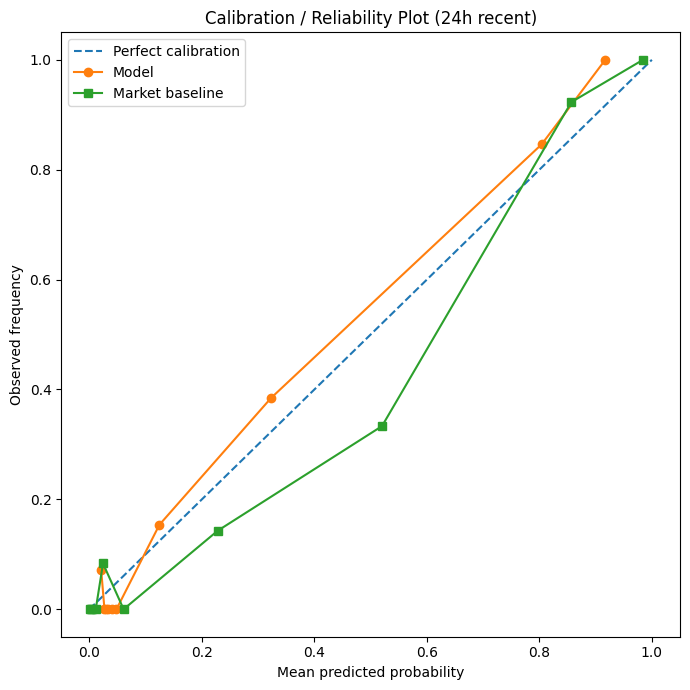

In [21]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy="quantile")
market_true, market_pred = calibration_curve(
    y_test,
    X_test["market_implied_prob"].astype(float).values,
    n_bins=10,
    strategy="quantile",
)

plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot(market_pred, market_true, marker="s", label="Market baseline")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration / Reliability Plot (24h recent)")
plt.legend()
plt.tight_layout()
plt.show()


In [22]:
classifier = model.named_steps["classifier"]
preprocessor_fitted = model.named_steps["preprocessor"]
feature_names = preprocessor_fitted.get_feature_names_out()
coefs = classifier.coef_[0]

coef_df = pd.DataFrame(
    {"feature": feature_names, "coefficient": coefs}
).sort_values("coefficient", ascending=False)

coef_df

,feature,coefficient
1,num__market_implied_prob,5.731809
2,num__log_volume,0.129386
0,num__duration_hours,0.000056
4,cat__category_None,0.000011
3,num__log_liquidity,-0.163000


In [23]:
classifier = model.named_steps["classifier"]
preprocessor_fitted = model.named_steps["preprocessor"]
feature_names = preprocessor_fitted.get_feature_names_out()
coefs = classifier.coef_[0]

coef_df = pd.DataFrame(
    {"feature": feature_names, "coefficient": coefs}
).sort_values("coefficient", ascending=False)

coef_df

,feature,coefficient
1,num__market_implied_prob,5.731809
2,num__log_volume,0.129386
0,num__duration_hours,0.000056
4,cat__category_None,0.000011
3,num__log_liquidity,-0.163000


In [25]:
import pandas as pd
import numpy as np

df_mid=pd.read_parquet("data/processed/features_mid_recent_enriched.parquet")
print(df_mid.shape)
df_mid.head(5)

(470, 19)


,market_id,platform,question,category,open_ts,close_ts,resolved_outcome,label_status,duration_hours,parsed_token_ids,parsed_outcomes,volume,liquidity,snapshot_type,target_ts,snapshot_ts,time_to_resolution_hours,market_token_id,market_implied_prob
0,255333,polymarket,Will X remove likes + reposts counter in March?,None,2024-03-07 17:29:32.817000+00:00,2024-03-31 00:00:00+00:00,0,no_won,558.507551,[390502963243644458096416646846798729364911156...,"[Yes, No]",11403.704168,NaN,mid,2024-03-19 08:44:46.408500+00:00,2024-03-19 08:44:46.408500+00:00,279.253775,3905029632436444580964166468467987293649111562...,0.0650
1,255335,polymarket,Fed rate cut by September 18?,None,2024-03-07 18:53:28.276000+00:00,2024-09-18 00:00:00+00:00,1,yes_won,4661.108812,[503767227679829767928194833216754761846835059...,"[Yes, No]",20345317.826273,NaN,mid,2024-06-12 21:26:44.138000+00:00,2024-06-12 21:26:44.138000+00:00,2330.554406,5037672276798297679281948332167547618468350597...,0.4350
2,255336,polymarket,Fed rate cut by November 7?,None,2024-03-07 18:53:28.351000+00:00,2024-11-07 00:00:00+00:00,1,yes_won,5861.108791,[932280236184104901011712822922629239951549608...,"[Yes, No]",2020982.792054,NaN,mid,2024-07-07 21:26:44.175500+00:00,2024-07-07 21:26:44.175500+00:00,2930.554396,9322802361841049010117128229226292399515496085...,0.7950
3,255337,polymarket,Fed rate cut by December 18?,None,2024-03-07 18:53:28.352000+00:00,2024-12-18 00:00:00+00:00,1,yes_won,6845.108791,[114348764082100671299495859311302103169701355...,"[Yes, No]",2269863.269023,NaN,mid,2024-07-28 09:26:44.176000+00:00,2024-07-28 09:26:44.176000+00:00,3422.554396,1143487640821006712994958593113021031697013551...,0.9165
4,255338,polymarket,Kung Fu Panda 4 over $48m opening weekend?,None,2024-03-07 18:57:06.892000+00:00,2024-03-11 00:00:00+00:00,1,yes_won,77.048086,[338364617365843636414142017467408647528299767...,"[Yes, No]",43947.033092,0,mid,2024-03-09 09:28:33.446000+00:00,2024-03-09 09:28:33.446000+00:00,38.524043,3383646173658436364141420174674086475282997676...,0.8000


In [26]:
cols= [
"question",
"resolved_outcome",
"market_implied_prob",
"duration_hours",
"volume",
"liquidity",
]
df_mid[cols].head(10)

,question,resolved_outcome,market_implied_prob,duration_hours,volume,liquidity
0,Will X remove likes + reposts counter in March?,0,0.0650,558.507551,11403.704168,NaN
1,Fed rate cut by September 18?,1,0.4350,4661.108812,20345317.826273,NaN
2,Fed rate cut by November 7?,1,0.7950,5861.108791,2020982.792054,NaN
3,Fed rate cut by December 18?,1,0.9165,6845.108791,2269863.269023,NaN
4,Kung Fu Panda 4 over $48m opening weekend?,1,0.8000,77.048086,43947.033092,0
5,Congress passes bill banning TikTok by April 30?,1,0.0550,1286.831173,146220.701385,NaN
6,TikTok sale announced in March?,0,0.0255,554.500192,12293.848341,NaN
7,Indian Election: Modi reelected?,1,0.9620,2004.990628,377942.060973,NaN
8,Will a Democrat win North Carolina Governor El...,1,0.5850,5803.640513,283661.747032,NaN
9,Will a Republican win North Carolina Governor ...,0,0.3700,5803.640463,545065.67519,NaN


In [28]:
df_mid=df_mid.copy()
df_mid["log_volume"]=np.log1p(pd.to_numeric(df_mid["volume"],errors="coerce"))
df_mid["log_liquidity"]=np.log1p(pd.to_numeric(df_mid["liquidity"],errors="coerce"))

df_mid=df_mid[df_mid["resolved_outcome"].notna()].copy()
df_mid=df_mid[df_mid["market_implied_prob"].notna()].copy()

print(df_mid.shape)

(431, 21)


In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

feature_cols = [
    "category",
    "duration_hours",
    "market_implied_prob",
    "log_volume",
    "log_liquidity",
]

X_mid = df_mid[feature_cols].copy()
y_mid = df_mid["resolved_outcome"].astype(int)

numeric_features = [
    "duration_hours",
    "market_implied_prob",
    "log_volume",
    "log_liquidity",
]
categorical_features = ["category"]

numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median"))]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

model_mid = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
    ]
)

X_train_mid, X_test_mid, y_train_mid, y_test_mid = train_test_split(
    X_mid,
    y_mid,
    test_size=0.3,
    random_state=42,
    stratify=y_mid,
)

model_mid.fit(X_train_mid, y_train_mid)
y_prob_mid = model_mid.predict_proba(X_test_mid)[:, 1]

model_brier_mid = brier_score_loss(y_test_mid, y_prob_mid)
market_brier_mid = brier_score_loss(
    y_test_mid,
    X_test_mid["market_implied_prob"].astype(float).values,
)

print("Rows used:", len(df_mid))
print("Train rows:", len(X_train_mid))
print("Test rows:", len(X_test_mid))
print("Model Brier:", round(model_brier_mid, 6))
print("Market baseline Brier:", round(market_brier_mid, 6))

Rows used: 431
Train rows: 301
Test rows: 130
Model Brier: 0.073328
Market baseline Brier: 0.070879


In [34]:
results_mid = X_test_mid.copy()
results_mid["actual"] = y_test_mid.values
results_mid["market_prob"] = X_test_mid["market_implied_prob"].values
results_mid["model_prob"] = y_prob_mid
results_mid["abs_model_error"] = (results_mid["model_prob"] - results_mid["actual"]).abs()
results_mid["abs_market_error"] = (results_mid["market_prob"] - results_mid["actual"]).abs()
results_mid["model_beats_market"] = results_mid["abs_model_error"] < results_mid["abs_market_error"]

results_mid[[
    "market_prob",
    "model_prob",
    "actual",
    "abs_market_error",
    "abs_model_error",
    "model_beats_market",
]].head(15)

,market_prob,model_prob,actual,abs_market_error,abs_model_error,model_beats_market
279,0.0350,0.043367,0,0.0350,0.043367,False
366,0.2450,0.131372,0,0.2450,0.131372,True
300,0.5150,0.385946,0,0.5150,0.385946,True
97,0.0090,0.054912,0,0.0090,0.054912,False
167,0.0095,0.038684,0,0.0095,0.038684,False
80,0.0080,0.060099,0,0.0080,0.060099,False
389,0.0100,0.076422,0,0.0100,0.076422,False
278,0.0110,0.037128,0,0.0110,0.037128,False
397,0.0305,0.047242,0,0.0305,0.047242,False
375,0.0340,0.044169,0,0.0340,0.044169,False


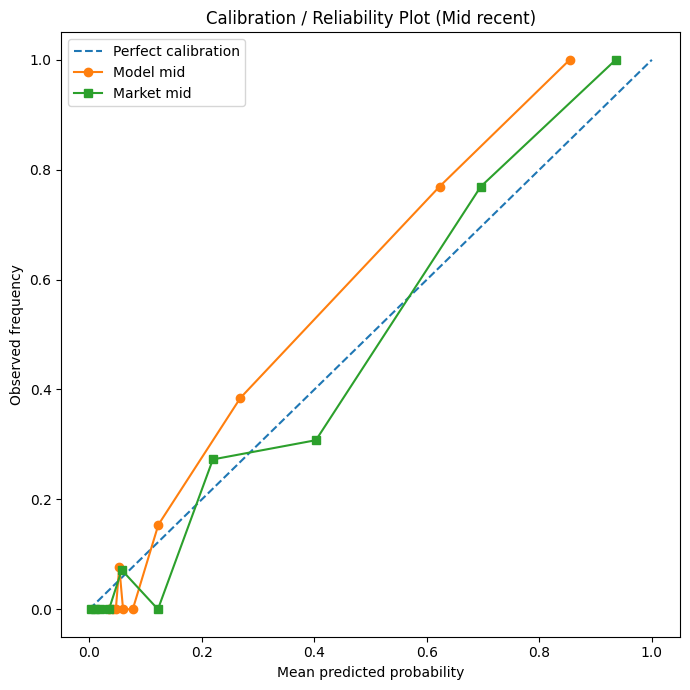

In [35]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

prob_true_mid, prob_pred_mid = calibration_curve(
    y_test_mid, y_prob_mid, n_bins=10, strategy="quantile"
)
market_true_mid, market_pred_mid = calibration_curve(
    y_test_mid,
    X_test_mid["market_implied_prob"].astype(float).values,
    n_bins=10,
    strategy="quantile",
)

plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.plot(prob_pred_mid, prob_true_mid, marker="o", label="Model mid")
plt.plot(market_pred_mid, market_true_mid, marker="s", label="Market mid")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration / Reliability Plot (Mid recent)")
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
classifier_mid = model_mid.named_steps["classifier"]
preprocessor_mid = model_mid.named_steps["preprocessor"]
feature_names_mid = preprocessor_mid.get_feature_names_out()
coefs_mid = classifier_mid.coef_[0]

coef_df_mid = pd.DataFrame(
    {"feature": feature_names_mid, "coefficient": coefs_mid}
).sort_values("coefficient", ascending=False)

coef_df_mid

,feature,coefficient
1,num__market_implied_prob,5.124990e+00
2,num__log_volume,1.219920e-01
4,cat__category_None,-2.078537e-07
0,num__duration_hours,-7.984456e-06
3,num__log_liquidity,-1.909405e-01


In [37]:
comparison = pd.DataFrame([
    {
        "snapshot": "24h",
        "rows_used": len(df),
        "model_brier": round(model_brier, 6),
        "market_brier": round(market_brier, 6),
        "model_beats_market": model_brier < market_brier,
    },
    {
        "snapshot": "mid",
        "rows_used": len(df_mid),
        "model_brier": round(model_brier_mid, 6),
        "market_brier": round(market_brier_mid, 6),
        "model_beats_market": model_brier_mid < market_brier_mid,
    },
])

comparison

,snapshot,rows_used,model_brier,market_brier,model_beats_market
0,24h,434,0.051627,0.052364,True
1,mid,431,0.073328,0.070879,False


In [38]:
import pandas as pd

open_df = pd.read_parquet("data/processed/features_open_recent.parquet")
mid_df = pd.read_parquet("data/processed/features_mid_recent_enriched.parquet")
t24_df = pd.read_parquet("data/processed/features_24h_recent_enriched.parquet")

print("open rows:", len(open_df))
print("mid rows:", len(mid_df))
print("24h rows:", len(t24_df))

print("\nopen columns:")
print(open_df.columns.tolist())

print("\nmid columns:")
print(mid_df.columns.tolist())

print("\n24h columns:")
print(t24_df.columns.tolist())

if "market_implied_prob" in mid_df.columns:
    print("\nmid non-null market_implied_prob:", mid_df["market_implied_prob"].notna().sum())
if "market_implied_prob" in t24_df.columns:
    print("24h non-null market_implied_prob:", t24_df["market_implied_prob"].notna().sum())

open rows: 470
mid rows: 470
24h rows: 470

open columns:
['market_id', 'platform', 'question', 'category', 'open_ts', 'close_ts', 'resolved_outcome', 'label_status', 'duration_hours', 'parsed_token_ids', 'parsed_outcomes', 'volume', 'liquidity', 'snapshot_type', 'target_ts', 'snapshot_ts', 'time_to_resolution_hours']

mid columns:
['market_id', 'platform', 'question', 'category', 'open_ts', 'close_ts', 'resolved_outcome', 'label_status', 'duration_hours', 'parsed_token_ids', 'parsed_outcomes', 'volume', 'liquidity', 'snapshot_type', 'target_ts', 'snapshot_ts', 'time_to_resolution_hours', 'market_token_id', 'market_implied_prob']

24h columns:
['market_id', 'platform', 'question', 'category', 'open_ts', 'close_ts', 'resolved_outcome', 'label_status', 'duration_hours', 'parsed_token_ids', 'parsed_outcomes', 'volume', 'liquidity', 'snapshot_type', 'target_ts', 'snapshot_ts', 'time_to_resolution_hours', 'market_token_id', 'market_implied_prob']

mid non-null market_implied_prob: 431
24h n

In [43]:
import pandas as pd

df24h_hist = pd.read_parquet("data/processed/features_24h_recent_history_enriched.parquet")
dfmid_hist = pd.read_parquet("data/processed/features_mid_recent_history_enriched.parquet")

print(df24h_hist.shape)
print(dfmid_hist.shape)

print(df24h_hist[[
    "market_implied_prob",
    "history_points_count",
    "distance_from_0_5",
    "prob_change_24h",
    "prob_change_12h",
    "realized_volatility",
]].head(10))

(470, 24)
(470, 24)
   market_implied_prob  history_points_count  distance_from_0_5  \
0               0.0550                    44             0.4450   
1               0.9835                   384             0.4835   
2               0.9940                   388             0.4940   
3               0.9955                   388             0.4955   
4               0.9745                     4             0.4745   
5               0.9880                    95             0.4880   
6               0.0050                    44             0.4950   
7               0.9550                   163             0.4550   
8               0.9550                   359             0.4550   
9               0.0385                   359             0.4615   

   prob_change_24h  prob_change_12h  realized_volatility  
0          -0.0050          -0.0050             0.007510  
1           0.0000           0.0005             0.027492  
2           0.0000           0.0000             0.019536  
3     

In [44]:
import pandas as pd

experiments = pd.DataFrame([
    {
        "experiment": "simple_baseline_24h",
        "snapshot": "24h",
        "rows_used": 434,
        "features": "market_implied_prob + duration_hours + log_volume + log_liquidity + category_fallback",
        "model_brier": 0.051627,
        "market_brier": 0.052364,
        "beats_market": True,
        "takeaway": "Simple model slightly beats market."
    },
    {
        "experiment": "history_baseline_24h",
        "snapshot": "24h",
        "rows_used": 434,
        "features": "simple features + distance_from_0_5 + prob_change_24h + prob_change_12h + realized_volatility + history_points_count",
        "model_brier": 0.053923,
        "market_brier": 0.052364,
        "beats_market": False,
        "takeaway": "History features hurt 24h performance."
    },
    {
        "experiment": "simple_baseline_mid",
        "snapshot": "mid",
        "rows_used": 431,
        "features": "market_implied_prob + duration_hours + log_volume + log_liquidity + category_fallback",
        "model_brier": 0.073328,
        "market_brier": 0.070879,
        "beats_market": False,
        "takeaway": "Market beats simple midpoint model."
    },
    {
        "experiment": "history_baseline_mid",
        "snapshot": "mid",
        "rows_used": 431,
        "features": "simple features + distance_from_0_5 + prob_change_24h + prob_change_12h + realized_volatility + history_points_count",
        "model_brier": 0.072874,
        "market_brier": 0.070879,
        "beats_market": False,
        "takeaway": "History features improve midpoint model slightly, but market still wins."
    },
])

experiments["delta_vs_market"] = experiments["model_brier"] - experiments["market_brier"]
experiments.sort_values(["snapshot", "model_brier"])

,experiment,snapshot,rows_used,features,model_brier,market_brier,beats_market,takeaway,delta_vs_market
0,simple_baseline_24h,24h,434,market_implied_prob + duration_hours + log_vol...,0.051627,0.052364,True,Simple model slightly beats market.,-0.000737
1,history_baseline_24h,24h,434,simple features + distance_from_0_5 + prob_cha...,0.053923,0.052364,False,History features hurt 24h performance.,0.001559
3,history_baseline_mid,mid,431,simple features + distance_from_0_5 + prob_cha...,0.072874,0.070879,False,History features improve midpoint model slight...,0.001995
2,simple_baseline_mid,mid,431,market_implied_prob + duration_hours + log_vol...,0.073328,0.070879,False,Market beats simple midpoint model.,0.002449


In [45]:
import pandas as pd

df24 = pd.read_parquet("data/processed/features_24h_recent_enriched.parquet")
df24h = pd.read_parquet("data/processed/features_24h_recent_history_enriched.parquet")

print("simple 24h shape:", df24.shape)
print("history 24h shape:", df24h.shape)
print(df24h.columns.tolist())

simple 24h shape: (446, 22)
history 24h shape: (446, 27)
['market_id', 'platform', 'question', 'category', 'category_fallback', 'open_ts', 'close_ts', 'resolved_outcome', 'label_status', 'duration_hours', 'parsed_token_ids', 'parsed_outcomes', 'volume', 'liquidity', 'volume_num', 'liquidity_num', 'snapshot_type', 'target_ts', 'snapshot_ts', 'time_to_resolution_hours', 'market_token_id', 'history_points_count', 'market_implied_prob', 'distance_from_0_5', 'prob_change_24h', 'prob_change_12h', 'realized_volatility']


In [46]:
print(df24h["resolved_outcome"].value_counts(dropna=False))
print(df24h["resolved_outcome"].value_counts(normalize=True, dropna=False))

resolved_outcome
0    337
1    109
Name: count, dtype: int64
resolved_outcome
0    0.755605
1    0.244395
Name: proportion, dtype: float64


In [48]:
print(df24h["category_fallback"].value_counts(dropna=False))
print(df24h["category_fallback"].value_counts(normalize=True, dropna=False))

category_fallback
Politics                 182
Other                    180
Crypto                    50
Sports                    21
Culture/Entertainment      8
Business/Tech              5
Name: count, dtype: int64
category_fallback
Politics                 0.408072
Other                    0.403587
Crypto                   0.112108
Sports                   0.047085
Culture/Entertainment    0.017937
Business/Tech            0.011211
Name: proportion, dtype: float64


In [49]:
missing = df24h.isna().mean().sort_values(ascending=False)
missing[missing > 0].head(30)

category               1.000000
liquidity_num          0.946188
liquidity              0.946188
prob_change_12h        0.031390
realized_volatility    0.031390
prob_change_24h        0.031390
market_implied_prob    0.026906
distance_from_0_5      0.026906
dtype: float64

In [50]:
num_cols = [
    "duration_hours",
    "market_implied_prob",
    "log_volume",
    "log_liquidity",
    "distance_from_0_5",
    "prob_change_24h",
    "prob_change_12h",
    "realized_volatility",
    "history_points_count",
]

df24h[num_cols].describe().T

KeyError: "['log_volume', 'log_liquidity'] not in index"

In [51]:
for col in num_cols:
    s = pd.to_numeric(df24h[col], errors="coerce")
    print("\n", col)
    print("min:", s.min(), "max:", s.max())
    print("p1:", s.quantile(0.01), "p99:", s.quantile(0.99))


 duration_hours
min: 41.73346100444444 max: 7147.275104485833
p1: 76.23569138169445 p99: 6991.90703023525

 market_implied_prob
min: 0.0005 max: 0.9995
p1: 0.0005 p99: 0.9995


KeyError: 'log_volume'

In [53]:
import numpy as np

df24h = df24h.copy()
df24h["log_volume"] = np.log1p(pd.to_numeric(df24h["volume"], errors="coerce"))
df24h["log_liquidity"] = np.log1p(pd.to_numeric(df24h["liquidity"], errors="coerce"))

In [54]:
num_cols = [
    "duration_hours",
    "market_implied_prob",
    "log_volume",
    "log_liquidity",
    "distance_from_0_5",
    "prob_change_24h",
    "prob_change_12h",
    "realized_volatility",
    "history_points_count",
]

df24h[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
duration_hours,446.0,2923.855279,2543.222113,41.733461,491.399214,1578.558487,5319.797860,7147.275104
market_implied_prob,434.0,0.270531,0.367718,0.000500,0.005500,0.030500,0.499875,0.999500
log_volume,446.0,10.934455,1.917646,7.269617,9.664305,10.688037,11.973455,17.293665
log_liquidity,24.0,1.421477,3.247577,0.000000,0.000000,0.000000,0.000000,8.764071
distance_from_0_5,434.0,0.407812,0.145943,0.000000,0.405000,0.481000,0.495500,0.499500
prob_change_24h,432.0,0.003443,0.081360,-0.550000,-0.001000,0.000000,0.000000,0.493000
prob_change_12h,432.0,0.004137,0.071914,-0.452500,-0.000500,0.000000,0.000000,0.493000
realized_volatility,432.0,0.045280,0.052874,0.000000,0.003695,0.025206,0.072633,0.341699
history_points_count,446.0,186.809417,188.567985,0.000000,19.000000,72.000000,411.000000,593.000000


In [55]:
for col in num_cols:
    s = pd.to_numeric(df24h[col], errors="coerce")
    print("\n", col)
    print("min:", s.min(), "max:", s.max())
    print("p1:", s.quantile(0.01), "p99:", s.quantile(0.99))


 duration_hours
min: 41.73346100444444 max: 7147.275104485833
p1: 76.23569138169445 p99: 6991.90703023525

 market_implied_prob
min: 0.0005 max: 0.9995
p1: 0.0005 p99: 0.9995

 log_volume
min: 7.269616749608169 max: 17.2936652203862
p1: 7.530015414688332 p99: 16.458255474001874

 log_liquidity
min: 0.0 max: 8.76407076294475
p1: 0.0 p99: 8.724290977682164

 distance_from_0_5
min: 0.0 max: 0.49950000000000006
p1: 0.00016499999999998187 p99: 0.49950000000000006

 prob_change_24h
min: -0.5499999999999999 max: 0.493
p1: -0.188805 p99: 0.4003949999999997

 prob_change_12h
min: -0.4525 max: 0.493
p1: -0.19674999999999995 p99: 0.35984999999999984

 realized_volatility
min: 0.0 max: 0.3416991854443515
p1: 6.327848502189893e-05 p99: 0.19677802402850195

 history_points_count
min: 0 max: 593
p1: 0.0 p99: 571.0


In [56]:
import pandas as pd
import numpy as np

df24 = pd.read_parquet("data/processed/features_24h_recent_enriched.parquet")
df24h = pd.read_parquet("data/processed/features_24h_recent_history_enriched.parquet")

df24h = df24h.copy()
df24h["log_volume"] = np.log1p(pd.to_numeric(df24h["volume"], errors="coerce"))
df24h["log_liquidity"] = np.log1p(pd.to_numeric(df24h["liquidity"], errors="coerce"))

num_cols = [
    "duration_hours",
    "market_implied_prob",
    "log_volume",
    "log_liquidity",
    "distance_from_0_5",
    "prob_change_24h",
    "prob_change_12h",
    "realized_volatility",
    "history_points_count",
]

df24h[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
duration_hours,446.0,2923.855279,2543.222113,41.733461,491.399214,1578.558487,5319.797860,7147.275104
market_implied_prob,434.0,0.270531,0.367718,0.000500,0.005500,0.030500,0.499875,0.999500
log_volume,446.0,10.934455,1.917646,7.269617,9.664305,10.688037,11.973455,17.293665
log_liquidity,24.0,1.421477,3.247577,0.000000,0.000000,0.000000,0.000000,8.764071
distance_from_0_5,434.0,0.407812,0.145943,0.000000,0.405000,0.481000,0.495500,0.499500
prob_change_24h,432.0,0.003443,0.081360,-0.550000,-0.001000,0.000000,0.000000,0.493000
prob_change_12h,432.0,0.004137,0.071914,-0.452500,-0.000500,0.000000,0.000000,0.493000
realized_volatility,432.0,0.045280,0.052874,0.000000,0.003695,0.025206,0.072633,0.341699
history_points_count,446.0,186.809417,188.567985,0.000000,19.000000,72.000000,411.000000,593.000000


In [57]:
for col in num_cols:
    s = pd.to_numeric(df24h[col], errors="coerce")
    print("\n", col)
    print("min:", s.min(), "max:", s.max())
    print("p1:", s.quantile(0.01), "p99:", s.quantile(0.99))


 duration_hours
min: 41.73346100444444 max: 7147.275104485833
p1: 76.23569138169445 p99: 6991.90703023525

 market_implied_prob
min: 0.0005 max: 0.9995
p1: 0.0005 p99: 0.9995

 log_volume
min: 7.269616749608169 max: 17.2936652203862
p1: 7.530015414688332 p99: 16.458255474001874

 log_liquidity
min: 0.0 max: 8.76407076294475
p1: 0.0 p99: 8.724290977682164

 distance_from_0_5
min: 0.0 max: 0.49950000000000006
p1: 0.00016499999999998187 p99: 0.49950000000000006

 prob_change_24h
min: -0.5499999999999999 max: 0.493
p1: -0.188805 p99: 0.4003949999999997

 prob_change_12h
min: -0.4525 max: 0.493
p1: -0.19674999999999995 p99: 0.35984999999999984

 realized_volatility
min: 0.0 max: 0.3416991854443515
p1: 6.327848502189893e-05 p99: 0.19677802402850195

 history_points_count
min: 0 max: 593
p1: 0.0 p99: 571.0


In [2]:
import pandas as pd

markets_recent = pd.read_parquet("data/processed/markets_recent.parquet")
features_mid = pd.read_parquet("data/processed/features_mid_recent_history_enriched.parquet")
features_24h = pd.read_parquet("data/processed/features_24h_recent_history_enriched.parquet")
current_poly = pd.read_parquet("data/processed/current_polymarket_scored_trained.parquet")
current_kalshi = pd.read_parquet("data/processed/kalshi_current_scored_trained.parquet")

print("markets_recent:", markets_recent.shape)
print("features_mid:", features_mid.shape)
print("features_24h:", features_24h.shape)
print("current_poly:", current_poly.shape)
print("current_kalshi:", current_kalshi.shape)

markets_recent: (470, 17)
features_mid: (470, 27)
features_24h: (446, 27)
current_poly: (71, 22)
current_kalshi: (2303, 27)


In [3]:
features_24h[[
    "question",
    "snapshot_ts",
    "open_ts",
    "close_ts",
    "market_implied_prob",
    "resolved_outcome"
]].head()

,question,snapshot_ts,open_ts,close_ts,market_implied_prob,resolved_outcome
0,Will X remove likes + reposts counter in March?,2024-03-30 00:00:00+00:00,2024-03-07 17:29:32.817000+00:00,2024-03-31 00:00:00+00:00,0.0550,0
1,Fed rate cut by September 18?,2024-09-17 00:00:00+00:00,2024-03-07 18:53:28.276000+00:00,2024-09-18 00:00:00+00:00,0.9835,1
2,Fed rate cut by November 7?,2024-11-06 00:00:00+00:00,2024-03-07 18:53:28.351000+00:00,2024-11-07 00:00:00+00:00,0.9940,1
3,Fed rate cut by December 18?,2024-12-17 00:00:00+00:00,2024-03-07 18:53:28.352000+00:00,2024-12-18 00:00:00+00:00,0.9955,1
4,Kung Fu Panda 4 over $48m opening weekend?,2024-03-10 00:00:00+00:00,2024-03-07 18:57:06.892000+00:00,2024-03-11 00:00:00+00:00,0.9745,1


In [4]:
offline_summary = pd.read_csv("reports/offline_snapshot_summary.csv")
offline_summary

,snapshot,rows_used,naive_brier,market_brier,model_brier,bss_vs_naive,bss_vs_market,takeaway
0,open,0,NaN,NaN,NaN,NaN,NaN,no usable rows
1,mid,431,0.25,0.073034,0.066848,0.732606,0.084691,model beats market
2,24h,434,0.25,0.046290,0.036892,0.852431,0.203027,model beats market


In [5]:
coef_df = pd.read_csv("reports/best_24h_coefficients.csv")
coef_df.head(15)

,feature,coefficient,abs_coefficient
0,num__market_implied_prob,3.143656,3.143656
1,cat__category_fallback_Crypto,-0.957730,0.957730
2,cat__category_fallback_Sports,0.560604,0.560604
3,num__history_points_count,-0.408132,0.408132
4,num__log_volume,0.370494,0.370494
5,num__duration_hours,0.350855,0.350855
6,cat__category_fallback_Politics,0.248039,0.248039
7,cat__category_fallback_Other,0.215858,0.215858
8,num__prob_change_24h,-0.177562,0.177562
9,num__distance_from_0_5,0.157901,0.157901


In [6]:
poly = pd.read_parquet("data/processed/current_polymarket_scored_trained.parquet")
poly[[
    "question",
    "category_fallback",
    "time_to_close_hours",
    "market_implied_prob",
    "model_prob",
    "model_minus_market",
    "abs_edge",
    "direction",
    "edge_bucket"
]].head(20)

,question,category_fallback,time_to_close_hours,market_implied_prob,model_prob,model_minus_market,abs_edge,direction,edge_bucket
0,Will the next Prime Minister of Hungary be Pét...,Other,623.109241,0.6450,0.806144,0.161144,0.161144,bullish_vs_market,large
1,Will Sweden qualify for the 2026 FIFA World Cup?,Sports,623.109241,0.2750,0.125200,-0.149800,0.149800,bearish_vs_market,medium
2,Will Ukraine qualify for the 2026 FIFA World Cup?,Sports,623.109241,0.2700,0.123899,-0.146101,0.146101,bearish_vs_market,medium
3,BitBoy convicted?,Other,347.109241,0.1795,0.038830,-0.140670,0.140670,bearish_vs_market,medium
4,Will Italy qualify for the 2026 FIFA World Cup?,Sports,623.109241,0.6400,0.746258,0.106258,0.106258,bullish_vs_market,medium
5,Will Scottie Scheffler win the 2026 Masters to...,Sports,647.109241,0.1850,0.081458,-0.103542,0.103542,bearish_vs_market,medium
6,Will Poland qualify for the 2026 FIFA World Cup?,Sports,623.109241,0.3550,0.253001,-0.101999,0.101999,bearish_vs_market,medium
7,Will the next Prime Minister of Hungary be Vik...,Other,623.109241,0.3450,0.248645,-0.096355,0.096355,bearish_vs_market,medium
8,Will the next Prime Minister of Hungary be Ist...,Other,623.109241,0.0035,0.062474,0.058974,0.058974,bullish_vs_market,small
9,Will Rory McIlroy win the 2026 Masters tournam...,Sports,647.109241,0.0850,0.033968,-0.051032,0.051032,bearish_vs_market,small


In [7]:
poly.sort_values("abs_edge", ascending=False)[[
    "question",
    "category_fallback",
    "time_to_close_hours",
    "market_implied_prob",
    "model_prob",
    "model_minus_market",
    "abs_edge",
    "direction",
    "edge_bucket"
]].head(10)

,question,category_fallback,time_to_close_hours,market_implied_prob,model_prob,model_minus_market,abs_edge,direction,edge_bucket
0,Will the next Prime Minister of Hungary be Pét...,Other,623.109241,0.6450,0.806144,0.161144,0.161144,bullish_vs_market,large
1,Will Sweden qualify for the 2026 FIFA World Cup?,Sports,623.109241,0.2750,0.125200,-0.149800,0.149800,bearish_vs_market,medium
2,Will Ukraine qualify for the 2026 FIFA World Cup?,Sports,623.109241,0.2700,0.123899,-0.146101,0.146101,bearish_vs_market,medium
3,BitBoy convicted?,Other,347.109241,0.1795,0.038830,-0.140670,0.140670,bearish_vs_market,medium
4,Will Italy qualify for the 2026 FIFA World Cup?,Sports,623.109241,0.6400,0.746258,0.106258,0.106258,bullish_vs_market,medium
5,Will Scottie Scheffler win the 2026 Masters to...,Sports,647.109241,0.1850,0.081458,-0.103542,0.103542,bearish_vs_market,medium
6,Will Poland qualify for the 2026 FIFA World Cup?,Sports,623.109241,0.3550,0.253001,-0.101999,0.101999,bearish_vs_market,medium
7,Will the next Prime Minister of Hungary be Vik...,Other,623.109241,0.3450,0.248645,-0.096355,0.096355,bearish_vs_market,medium
8,Will the next Prime Minister of Hungary be Ist...,Other,623.109241,0.0035,0.062474,0.058974,0.058974,bullish_vs_market,small
9,Will Rory McIlroy win the 2026 Masters tournam...,Sports,647.109241,0.0850,0.033968,-0.051032,0.051032,bearish_vs_market,small


In [8]:
kalshi = pd.read_parquet("data/processed/kalshi_current_scored_trained.parquet")
kalshi[[
    "question",
    "category_fallback",
    "confidence_band",
    "time_to_close_hours",
    "volume_num",
    "open_interest_num",
    "market_implied_prob",
    "model_prob",
    "model_minus_market",
    "abs_edge"
]].head(20)

,question,category_fallback,confidence_band,time_to_close_hours,volume_num,open_interest_num,market_implied_prob,model_prob,model_minus_market,abs_edge
0,Will the WTI front-month settle oil price be ...,Macro/Commodities,exploratory,13.766126,14.0,14.0,0.510,0.088164,-0.421836,0.421836
1,What will any participating contestant say dur...,Culture/Entertainment,exploratory,33.266126,44.0,21.0,0.500,0.095467,-0.404533,0.404533
2,Will the silver open price be above $82.49 on ...,Macro/Commodities,exploratory,64.266126,30.0,30.0,0.490,0.086280,-0.403720,0.403720
3,"SOL price on Mar 20, 2026?",Crypto,exploratory,64.266126,204.0,16.0,0.725,0.332098,-0.392902,0.392902
4,What will Tulsi Gabbard say during House Intel...,Politics,exploratory,9.266126,23.0,23.0,0.515,0.124616,-0.390384,0.390384
5,What will Trey the Triceratops (Sub-Adult Tric...,Other,exploratory,335.249459,31.0,31.0,0.495,0.116877,-0.378123,0.378123
6,Evan Mobley: Double Double,Other,exploratory,331.266126,40.0,40.0,0.510,0.132063,-0.377937,0.377937
7,Venezuela vs USA first 5 innings runs?,Sports,exploratory,43.266126,10.0,10.0,0.505,0.132370,-0.372630,0.372630
8,What will Kash Patel say during House Intellig...,Politics,exploratory,9.266126,19.0,11.0,0.585,0.212542,-0.372458,0.372458
9,Will UST Par Yield Curve (30Y) for Q1 2026 be ...,Macro/Commodities,exploratory,326.749459,42.0,42.0,0.430,0.064670,-0.365330,0.365330


In [9]:
kalshi["confidence_band"].value_counts(dropna=False)

confidence_band
exploratory        1389
high_confidence     914
Name: count, dtype: int64

In [10]:
kalshi[kalshi["confidence_band"] == "high_confidence"].sort_values(
    "abs_edge", ascending=False
)[[
    "question",
    "category_fallback",
    "time_to_close_hours",
    "volume_num",
    "open_interest_num",
    "market_implied_prob",
    "model_prob",
    "model_minus_market",
    "abs_edge"
]].head(10)

,question,category_fallback,time_to_close_hours,volume_num,open_interest_num,market_implied_prob,model_prob,model_minus_market,abs_edge
1389,"SOL price on Mar 20, 2026?",Crypto,64.266126,423.0,220.0,0.610,0.158788,-0.451212,0.451212
1390,"SOL price on Mar 20, 2026?",Crypto,64.266126,603.0,144.0,0.490,0.060976,-0.429024,0.429024
1391,"Ethereum price at Mar 20, 2026 at 5pm EDT?",Crypto,64.266126,970.0,361.0,0.620,0.196091,-0.423909,0.423909
1392,"SOL price on Mar 20, 2026?",Crypto,64.266126,501.0,232.0,0.660,0.240020,-0.419980,0.419980
1393,"SOL price on Mar 20, 2026?",Crypto,64.266126,1377.0,373.0,0.490,0.070755,-0.419245,0.419245
1394,"Ethereum price at Mar 20, 2026 at 5pm EDT?",Crypto,64.266126,2937.0,1352.0,0.525,0.107821,-0.417179,0.417179
1395,"SOL price on Mar 20, 2026?",Crypto,64.266126,261.0,184.0,0.425,0.032878,-0.392122,0.392122
1396,"Bitcoin price on Mar 20, 2026?",Crypto,64.266126,8339.0,4210.0,0.470,0.084933,-0.385067,0.385067
1397,"Ethereum price at Mar 20, 2026 at 5pm EDT?",Crypto,64.266126,1873.0,1556.0,0.435,0.050836,-0.384164,0.384164
1398,"Bitcoin price on Mar 20, 2026?",Crypto,64.266126,17116.0,10229.0,0.520,0.139287,-0.380713,0.380713
